# `find_and_suppress` on MIDOG++ -- simplest configuration at `score_threshold=0.75`

**Purpose.** A re-run of
[`find_and_suppress_midog_simple.ipynb`](find_and_suppress_midog_simple.ipynb) with
**one parameter changed**: the score floor applied to correlation peaks before
non-maximum suppression, raised from `0.5` to `0.75`. Everything else is held fixed --
same seven ROIs, same `seed=0` draw, same binary-Otsu bbox tightening, one template per
seed at angle 0 with no flip and no multi-scale, and the same three channels
(`rgb`, `hematoxylin`, `gray_inverted`).

**Which knob this is.** "The threshold for the NMS score" is read here as
`FSConfig.score_threshold` -- the score cutoff in
[`template_match.extract_peaks`](midog_utils/template_match.py#L188), applied to the fused
`TM_CCOEFF_NORMED` map to select the candidate peaks that then go into
`nms.nms_by_distance`. The other threshold-shaped knob in the config, `nms_radius`, is a
distance in pixels rather than a score and is left untouched (it stays tied to each
image's evaluation match radius).

**The question this notebook is set up to answer.** Does raising the floor make the
results *more decisive* and *better in general*? Those are two different claims and this
notebook separates them:

- *more decisive* -- shorter, cleaner detection lists, less ROI tiling, higher precision;
- *better* -- more mitotic figures actually recovered at a fixed budget, i.e. a better
  detector.

The section immediately below argues from the pipeline's own structure that the second
claim **cannot** be true -- the answer is forced, not empirical -- and then the run is
used to confirm the prediction rather than to discover it.

**Environment.** `requirements-midog-utils.txt` (numpy < 2, pinned opencv/tifffile) --
Python 3.11.5 / numpy 1.26.4 / opencv 4.8.1.

In [1]:
import sys, time
sys.path.insert(0, '..') if 'midog_utils' not in __import__('os').listdir('.') else None

import numpy as np, pandas as pd, matplotlib.pyplot as plt

from midog_utils import dataset as ds, channels as ch, template_match as tm
from midog_utils import find_and_suppress as fs, evaluate as ev, experiment as ex, viz

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

SCORE_THRESHOLD = 0.75          # the one change; 0.5 is FSConfig's default and the
BASELINE_THRESHOLD = 0.5        # value the comparison notebook ran at

images, annotations = ds.load_annotations('databases/MIDOG++.json')
ds.check_invariants(annotations)          # every bbox is 50x50 and TLBR, or this raises
print(f'{len(images)} annotated images, {len(annotations)} annotations')

503 annotated images, 26286 annotations


## Which images

Unchanged: one ROI per tumour domain, the downloaded image with the most mitotic figures
(ties to the lower id). Same optimistic selection rule as every run in this series -- see
[`find_and_suppress_midog.ipynb`](find_and_suppress_midog.ipynb).

In [2]:
selection = ex.select_domain_images(images, annotations)
selection[['image_id', 'file_name', 'tumor_type', 'n_mitotic']]

,image_id,file_name,tumor_type,n_mitotic
0,301,301.tiff,canine cutaneous mast cell tumor,218
1,201,201.tiff,canine lung cancer,18
2,246,246.tiff,canine lymphosarcoma,116
3,405,405.tiff,canine soft tissue sarcoma,14
4,2,002.tiff,human breast cancer,9
5,506,506.tiff,human melanoma,12
6,350,350.tiff,human neuroendocrine tumor,4


## Configuration, and why the outcome is predictable before the run

`score_threshold=0.75` is the only override beyond the channel. The cell below asserts
that against `FSConfig`'s own defaults rather than trusting it.

**Raising this floor cannot add a detection, and cannot reorder the ones it keeps.**
Three facts about the pipeline, in order:

1. `extract_peaks` finds local maxima with a grey dilation
   (`fused >= dilate(fused)`), *then* intersects with `fused >= score_threshold`
   ([template_match.py:188](midog_utils/template_match.py#L188)). The local-maximum test
   never reads the threshold, so the candidate set at 0.75 is exactly the candidate set
   at 0.5 filtered to `score >= 0.75`.
2. `max_peaks` is 250 000, above the theoretical maximum for these ROIs, so the cap does
   not bind and no candidate is dropped for being ranked too low.
3. `nms_by_distance` is **greedy in descending score order**
   ([nms.py:37](midog_utils/nms.py#L37)). A peak scoring `>= 0.75` can only ever be
   suppressed by a peak with a *higher* score -- which is also `>= 0.75`, and therefore
   also present in the 0.75 candidate set. Removing peaks below 0.75 before NMS cannot
   change which peaks above 0.75 survive it.

So, exactly:

> `detections@0.75` = `{d in detections@0.5 : d.score >= 0.75}`, with the same ranks in
> the same order.

Two consequences follow, and they are the whole answer to "is it better":

- **`recall@K` can only stay equal or fall.** If the 0.75 list still holds at least `K`
  detections, its top-`K` is byte-identical to the 0.5 run's top-`K`, so `recall@K` is
  *identical*. If it holds fewer than `K`, the list is a strict prefix of the old
  top-`K`, so every true positive that sat between the new list's end and rank `K` is
  lost. There is no third case, and no case in which the number rises.
- **The FROC curve does not change; only where it stops does.** The curve is the
  cumulative TP/FP walk down the ranked list, so the 0.75 curve is an initial segment of
  the 0.5 curve. `sens@Xfp` is unchanged wherever the truncated curve still reaches, and
  0 where it does not.

The threshold is an **operating point on a fixed curve**, not a change to the curve. The
rest of this notebook measures how far the operating point moves, and confirms that
nothing else does.

In [3]:
cfg = fs.FSConfig(channel='rgb', score_threshold=SCORE_THRESHOLD)
cfg_base = fs.FSConfig(channel='rgb')       # the 0.5 configuration this run mirrors

from dataclasses import asdict, fields
diffs = {f.name for f in fields(cfg) if asdict(cfg)[f.name] != asdict(cfg_base)[f.name]}
assert diffs == {'score_threshold'}, f'unintended config differences: {diffs}'
assert cfg_base.score_threshold == BASELINE_THRESHOLD
print(f'OK: this run differs from the 0.5 run in `score_threshold` only '
      f'({cfg_base.score_threshold} -> {cfg.score_threshold}).')
print(cfg)
print(f'\n{cfg.n_augmentations} augmentation(s) per run '
      f'({cfg.n_angles} rotation x {len(cfg.flips)} flip x {len(cfg.scales)} scale)')

OK: this run differs from the 0.5 run in `score_threshold` only (0.5 -> 0.75).
FSConfig(channel='rgb', base_size=51, patch_size=73, scales=(1.0,), n_angles=1, flips=(False,), peak_min_distance=7, score_threshold=0.75, max_peaks=250000, nms_radius=None, self_hit_radius=5.0, max_detections=1000000000, scale_normalize=False)

1 augmentation(s) per run (1 rotation x 1 flip x 1 scale)


### The prediction, written down before the run

The 0.5 run saved its full detection lists, with scores, to
`results/fs_simple_detections.csv`. Under the argument above, the 0.75 detection list per
image is *derivable* from that file -- so the expected `recall@K` for every row can be
computed here, before any correlation is recomputed. The run then either reproduces these
numbers or reveals that one of the three facts above is wrong.

In [4]:
old_det = pd.read_csv('results/fs_simple_detections.csv')
old_met = pd.read_csv('results/fs_simple_metrics.csv')
old_fs = old_met[old_met.method == 'find_and_suppress'].set_index('file_name')

rows = []
for fn, g in old_det.groupby('file_name'):
    g = g.sort_values('rank')
    k = int(old_fs.loc[fn, 'k'])
    n_mit = int(old_fs.loc[fn, 'n_gt_mitotic_eval'])
    kept = g[g.score >= SCORE_THRESHOLD]
    # recall@K over the surviving prefix, using the buckets the 0.5 run already assigned.
    tp_new = int((kept.head(k)['bucket'] == ev.HUMAN_CORRECT_LABEL).sum())
    rows.append({
        'file_name': fn, 'K': k,
        'n_det@0.5': len(g), 'n_det@0.75': len(kept),
        'max_score': round(float(g.score.max()), 3),
        'list_shorter_than_K': len(kept) < k,
        'recall@K_0.5': round(float(old_fs.loc[fn, 'recall_at_k']), 3),
        'predicted_recall@K_0.75': round(tp_new / n_mit, 3),
    })
predicted = pd.DataFrame(rows).merge(
    selection[['file_name', 'tumor_type']], on='file_name').sort_values('tumor_type')
predicted = predicted[['tumor_type', 'file_name', 'K', 'max_score', 'n_det@0.5',
                       'n_det@0.75', 'list_shorter_than_K',
                       'recall@K_0.5', 'predicted_recall@K_0.75']].reset_index(drop=True)
predicted

,tumor_type,file_name,K,max_score,n_det@0.5,n_det@0.75,list_shorter_than_K,recall@K_0.5,predicted_recall@K_0.75
0,canine cutaneous mast cell tumor,301.tiff,217,0.904,13353,881,False,0.304,0.304
1,canine lung cancer,201.tiff,17,0.636,127,0,True,0.118,0.000
2,canine lymphosarcoma,246.tiff,115,0.599,5,0,True,0.017,0.000
3,canine soft tissue sarcoma,405.tiff,13,0.829,4479,51,False,0.000,0.000
4,human breast cancer,002.tiff,8,0.808,3621,42,False,0.250,0.250
5,human melanoma,506.tiff,11,0.736,2067,0,True,0.091,0.000
6,human neuroendocrine tumor,350.tiff,3,0.778,1940,4,False,0.000,0.000


Read the `max_score` column first: it is the best score any *genuine* (non-self) match
achieved in that ROI at 0.5. Wherever it sits below 0.75 the entire detection list is
wiped out and `recall@K` is forced to 0 -- not because the detector got worse, but
because the floor was set above everything it found.

## Run

Same driver, same `seed=0`, baselines included for the RGB run. Note the baselines are
*not* fully threshold-independent: `nucleus_blobs`' own `recall@K` is, but
`random_in_tissue` draws `n = len(detections)` points and is therefore budget-matched to
whatever the matcher returns -- so it shrinks with the list too, and on an empty list it
is empty.

In [5]:
t0 = time.time()
results, metrics, detections = ex.run_experiment(selection, annotations, cfg=cfg, seed=0)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics.to_csv('results/fs_t075_metrics.csv', index=False)
detections.to_csv('results/fs_t075_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 


    recall@K=0.304  attraction@K=0.138  coverage=0.08  (18s)


=== 201.tiff  (canine lung cancer, 18 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.00  (17s)


=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 


...

=== 506.tiff  (human melanoma, 12 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.00  (19s)


=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.00  (21s)



total 119s


### Verification: is the run exactly the 0.5 list, filtered?

Two independent checks. First, set equality of the detection lists themselves. Second,
whether the `recall@K` predicted above from the *saved* 0.5 file matches what the
re-run actually produced -- any disagreement there is a real bug, not noise.

(`np.argsort`'s default quicksort is not stable, so two peaks with bit-identical scores
sitting within `nms_radius` of each other could in principle swap survivors between runs.
A handful of coordinate mismatches would be tie-ordering; a systematic difference would
not.)

In [6]:
new_det = detections
mismatch_rows = []
for fn in selection.file_name:
    old_kept = old_det[(old_det.file_name == fn) & (old_det.score >= SCORE_THRESHOLD)]
    new_kept = new_det[new_det.file_name == fn]
    a = set(zip(old_kept.cx.round(3), old_kept.cy.round(3)))
    b = set(zip(new_kept.cx.round(3), new_kept.cy.round(3)))
    mismatch_rows.append({'file_name': fn, 'n_expected': len(a), 'n_actual': len(b),
                          'only_in_expected': len(a - b), 'only_in_actual': len(b - a)})
equivalence = pd.DataFrame(mismatch_rows)
print(equivalence.to_string(index=False))

new_fs = metrics[metrics.method == 'find_and_suppress'].set_index('file_name')
check = predicted.set_index('file_name')[['predicted_recall@K_0.75']].join(
    new_fs['recall_at_k'].round(3).rename('observed_recall@K_0.75'))
check['agrees'] = np.isclose(check['predicted_recall@K_0.75'], check['observed_recall@K_0.75'])
print()
print(check.to_string())
assert check.agrees.all(), 'predicted and observed recall@K disagree -- investigate'
print('\nOK: every observed recall@K matches the value predicted from the 0.5 run.')

file_name  n_expected  n_actual  only_in_expected  only_in_actual
 301.tiff         881       881                 0               0
 201.tiff           0         0                 0               0
 246.tiff           0         0                 0               0
 405.tiff          51        51                 0               0
 002.tiff          42        42                 0               0
 506.tiff           0         0                 0               0
 350.tiff           4         4                 0               0

           predicted_recall@K_0.75  observed_recall@K_0.75  agrees
file_name                                                         
301.tiff                     0.304                   0.304    True
201.tiff                     0.000                   0.000    True
246.tiff                     0.000                   0.000    True
405.tiff                     0.000                   0.000    True
002.tiff                     0.250                   0.250    True
50

## Results

### Headline: `recall@K`

`K` = the ROI's mitotic count minus the seed, as in every notebook in this series.

In [7]:
ex.summary_table(metrics)

,tumor_type,file_name,method,n_gt_mitotic_eval,n_lookalike_gt,recall_at_k,lookalike_attraction_at_k,topk_tp,topk_fp_lookalike,topk_fp_unannotated,sens@8fp_mm2,sens@64fp_mm2,n_unanimous,recall_unanimous_at_k,n_contested,recall_contested_at_k,max_detection_score,n_detections_total
0,canine cutaneous mast cell tumor,301.tiff,find_and_suppress,217,109,0.304147,0.137615,66,15,136,0.119816,0.267281,163,0.355828,54,0.148148,0.904356,881
1,canine lung cancer,201.tiff,find_and_suppress,17,49,0.000000,0.000000,0,0,0,0.000000,0.000000,6,0.000000,11,0.000000,NaN,0
2,canine lymphosarcoma,246.tiff,find_and_suppress,115,123,0.000000,0.000000,0,0,0,0.000000,0.000000,99,0.000000,16,0.000000,NaN,0
3,canine soft tissue sarcoma,405.tiff,find_and_suppress,13,19,0.000000,0.000000,0,0,13,0.000000,0.000000,9,0.000000,4,0.000000,0.828673,51
4,human breast cancer,002.tiff,find_and_suppress,8,7,0.250000,0.000000,2,0,6,0.250000,0.250000,6,0.333333,2,0.000000,0.808039,42
5,human melanoma,506.tiff,find_and_suppress,11,12,0.000000,0.000000,0,0,0,0.000000,0.000000,7,0.000000,4,0.000000,NaN,0
6,human neuroendocrine tumor,350.tiff,find_and_suppress,3,16,0.000000,0.000000,0,0,3,0.000000,0.000000,0,NaN,3,0.000000,0.777925,4


### 0.5 against 0.75, side by side

The direct answer to "did it get better". `delta_recall@K` is the 0.75 value minus the
0.5 value -- by the argument above it can only be `0` or negative.

In [8]:
cmp = predicted[['tumor_type', 'file_name', 'K', 'max_score',
                 'n_det@0.5', 'n_det@0.75', 'recall@K_0.5']].copy()
cmp['recall@K_0.75'] = cmp.file_name.map(new_fs['recall_at_k'].round(3))
cmp['delta_recall@K'] = (cmp['recall@K_0.75'] - cmp['recall@K_0.5']).round(3)
cmp['coverage_0.5'] = cmp.file_name.map(old_fs['coverage_frac'])
cmp['coverage_0.75'] = cmp.file_name.map(new_fs['coverage_frac'])
cmp['precision_0.5'] = cmp.file_name.map(old_fs['all_precision_mitotic'].round(4))
cmp['precision_0.75'] = cmp.file_name.map(new_fs['all_precision_mitotic'].round(4))
cmp['sens@64fp_0.5'] = cmp.file_name.map(old_fs['sens@64fp_mm2'].round(3))
cmp['sens@64fp_0.75'] = cmp.file_name.map(new_fs['sens@64fp_mm2'].round(3))
cmp

,tumor_type,file_name,K,max_score,n_det@0.5,n_det@0.75,recall@K_0.5,recall@K_0.75,delta_recall@K,coverage_0.5,coverage_0.75,precision_0.5,precision_0.75,sens@64fp_0.5,sens@64fp_0.75
0,canine cutaneous mast cell tumor,301.tiff,217,0.904,13353,881,0.304,0.304,0.000,0.8357,0.0752,0.0154,0.1237,0.267,0.267
1,canine lung cancer,201.tiff,17,0.636,127,0,0.118,0.000,-0.118,0.0111,0.0000,0.0236,0.0000,0.176,0.000
2,canine lymphosarcoma,246.tiff,115,0.599,5,0,0.017,0.000,-0.017,0.0005,0.0000,0.4000,0.0000,0.017,0.000
3,canine soft tissue sarcoma,405.tiff,13,0.829,4479,51,0.000,0.000,0.000,0.3723,0.0045,0.0029,0.0000,0.308,0.000
4,human breast cancer,002.tiff,8,0.808,3621,42,0.250,0.250,0.000,0.2893,0.0037,0.0019,0.0476,0.250,0.250
5,human melanoma,506.tiff,11,0.736,2067,0,0.091,0.000,-0.091,0.1683,0.0000,0.0024,0.0000,0.091,0.000
6,human neuroendocrine tumor,350.tiff,3,0.778,1940,4,0.000,0.000,0.000,0.1605,0.0003,0.0005,0.0000,0.000,0.000


In [9]:
print(f"rows where recall@K improved: {(cmp['delta_recall@K'] > 0).sum()} / {len(cmp)}")
print(f"rows unchanged:               {(cmp['delta_recall@K'] == 0).sum()} / {len(cmp)}")
print(f"rows that got worse:          {(cmp['delta_recall@K'] < 0).sum()} / {len(cmp)}")
print(f"\nmean recall@K   0.5 -> 0.75:  {cmp['recall@K_0.5'].mean():.3f} -> {cmp['recall@K_0.75'].mean():.3f}")
print(f"mean coverage   0.5 -> 0.75:  {cmp['coverage_0.5'].mean():.3f} -> {cmp['coverage_0.75'].mean():.3f}")
print(f"total detections 0.5 -> 0.75: {cmp['n_det@0.5'].sum()} -> {cmp['n_det@0.75'].sum()}")

rows where recall@K improved: 0 / 7
rows unchanged:               4 / 7
rows that got worse:          3 / 7

mean recall@K   0.5 -> 0.75:  0.111 -> 0.079
mean coverage   0.5 -> 0.75:  0.263 -> 0.012
total detections 0.5 -> 0.75: 25592 -> 978


**On `precision_*` and `coverage_*` as evidence of "decisiveness".** Neither is evidence
the detector improved, and `precision` does not even move in one direction. Truncating a
ranked list at a higher score raises precision only while the surviving prefix still
contains a true positive -- true on 301.tiff (0.015 -> 0.124) and 002.tiff
(0.002 -> 0.048), and false on the other five rows here, where the cut lands above every
hit and precision drops to 0 (0/51 on 405.tiff, 0/4 on 350.tiff) or becomes an undefined
0/0 printed as 0.0000 on the three ROIs that emptied. `coverage_frac` falls everywhere,
mechanically, because the list is shorter. Both describe the operating point, not the
curve. The one thing they buy is interpretability: at 0.5 the `coverage_frac` values were
high enough on several ROIs that full-list recall was partly a statement about the list
tiling the image (see [`evaluate.py`](midog_utils/evaluate.py)'s module docstring). That
confound is smaller here -- on rows where anything survives at all.

### Against the baselines

`nucleus_blobs` (any dark blob, hematoxylin channel) and `random_in_tissue` (the floor),
at the same top-`K` budget.

In [10]:
pivot = metrics.pivot_table(index=['tumor_type', 'file_name'], columns='method',
                            values='recall_at_k').round(3)
pivot['lift_vs_blobs'] = (pivot['find_and_suppress'] /
                          pivot['nucleus_blobs'].replace(0, np.nan)).round(2)
pivot

,method,find_and_suppress,nucleus_blobs,random_in_tissue,lift_vs_blobs
tumor_type,file_name,,,,
canine cutaneous mast cell tumor,301.tiff,0.304,0.594,0.018,0.51
canine lung cancer,201.tiff,0.000,0.235,0.000,0.00
canine lymphosarcoma,246.tiff,0.000,0.330,0.000,0.00
canine soft tissue sarcoma,405.tiff,0.000,0.000,0.000,NaN
human breast cancer,002.tiff,0.250,0.000,0.000,NaN
human melanoma,506.tiff,0.000,0.000,0.000,NaN
human neuroendocrine tumor,350.tiff,0.000,0.000,0.000,NaN


### Every detection, not just the top K

In [11]:
ex.full_list_table(metrics)

,tumor_type,file_name,all_n_detections,coverage_frac,all_tp,all_fp_lookalike,all_fp_unannotated,all_matched_any_gt,all_matched_frac,all_precision_mitotic,all_mitotic_gt_found,all_mitotic_gt_missed,all_lookalike_gt_found,all_lookalike_gt_missed
0,canine cutaneous mast cell tumor,301.tiff,881,0.0752,109,27,745,136,0.154370,0.123723,109,108,27,82
1,canine lung cancer,201.tiff,0,0.0000,0,0,0,0,0.000000,0.000000,0,17,0,49
2,canine lymphosarcoma,246.tiff,0,0.0000,0,0,0,0,0.000000,0.000000,0,115,0,123
3,canine soft tissue sarcoma,405.tiff,51,0.0045,0,2,49,2,0.039216,0.000000,0,13,2,17
4,human breast cancer,002.tiff,42,0.0037,2,1,39,3,0.071429,0.047619,2,6,1,6
5,human melanoma,506.tiff,0,0.0000,0,0,0,0,0.000000,0.000000,0,11,0,12
6,human neuroendocrine tumor,350.tiff,4,0.0003,0,0,4,0,0.000000,0.000000,0,3,0,16


### Expert-agreement split

Mitotic recall split by whether every rater who saw the annotation called it mitotic, at
the same `K`.

In [12]:
metrics[metrics.method == 'find_and_suppress'][
    ['tumor_type', 'file_name', 'k', 'tightened_base_size', 'seed_agreement_flagged',
     'n_unanimous', 'recall_unanimous_at_k', 'n_contested', 'recall_contested_at_k']
].sort_values('tumor_type').reset_index(drop=True)

,tumor_type,file_name,k,tightened_base_size,seed_agreement_flagged,n_unanimous,recall_unanimous_at_k,n_contested,recall_contested_at_k
0,canine cutaneous mast cell tumor,301.tiff,217,35.0,False,163,0.355828,54,0.148148
1,canine lung cancer,201.tiff,17,51.0,False,6,0.000000,11,0.000000
2,canine lymphosarcoma,246.tiff,115,51.0,False,99,0.000000,16,0.000000
3,canine soft tissue sarcoma,405.tiff,13,51.0,False,9,0.000000,4,0.000000
4,human breast cancer,002.tiff,8,35.0,False,6,0.333333,2,0.000000
5,human melanoma,506.tiff,11,43.0,False,7,0.000000,4,0.000000
6,human neuroendocrine tumor,350.tiff,3,41.0,True,0,NaN,3,0.000000


### FROC: the same curve, stopped earlier

The 0.5 curve is recomputed exactly from the saved 0.5 detection list (`evaluate.froc` is
a cumulative walk over the `bucket` column, so this needs no re-correlation), with the
0.75 curve drawn over it and a marker where the 0.75 list ends. If the argument at the
top of the notebook holds, the orange curve lies *on* the blue one and simply stops.

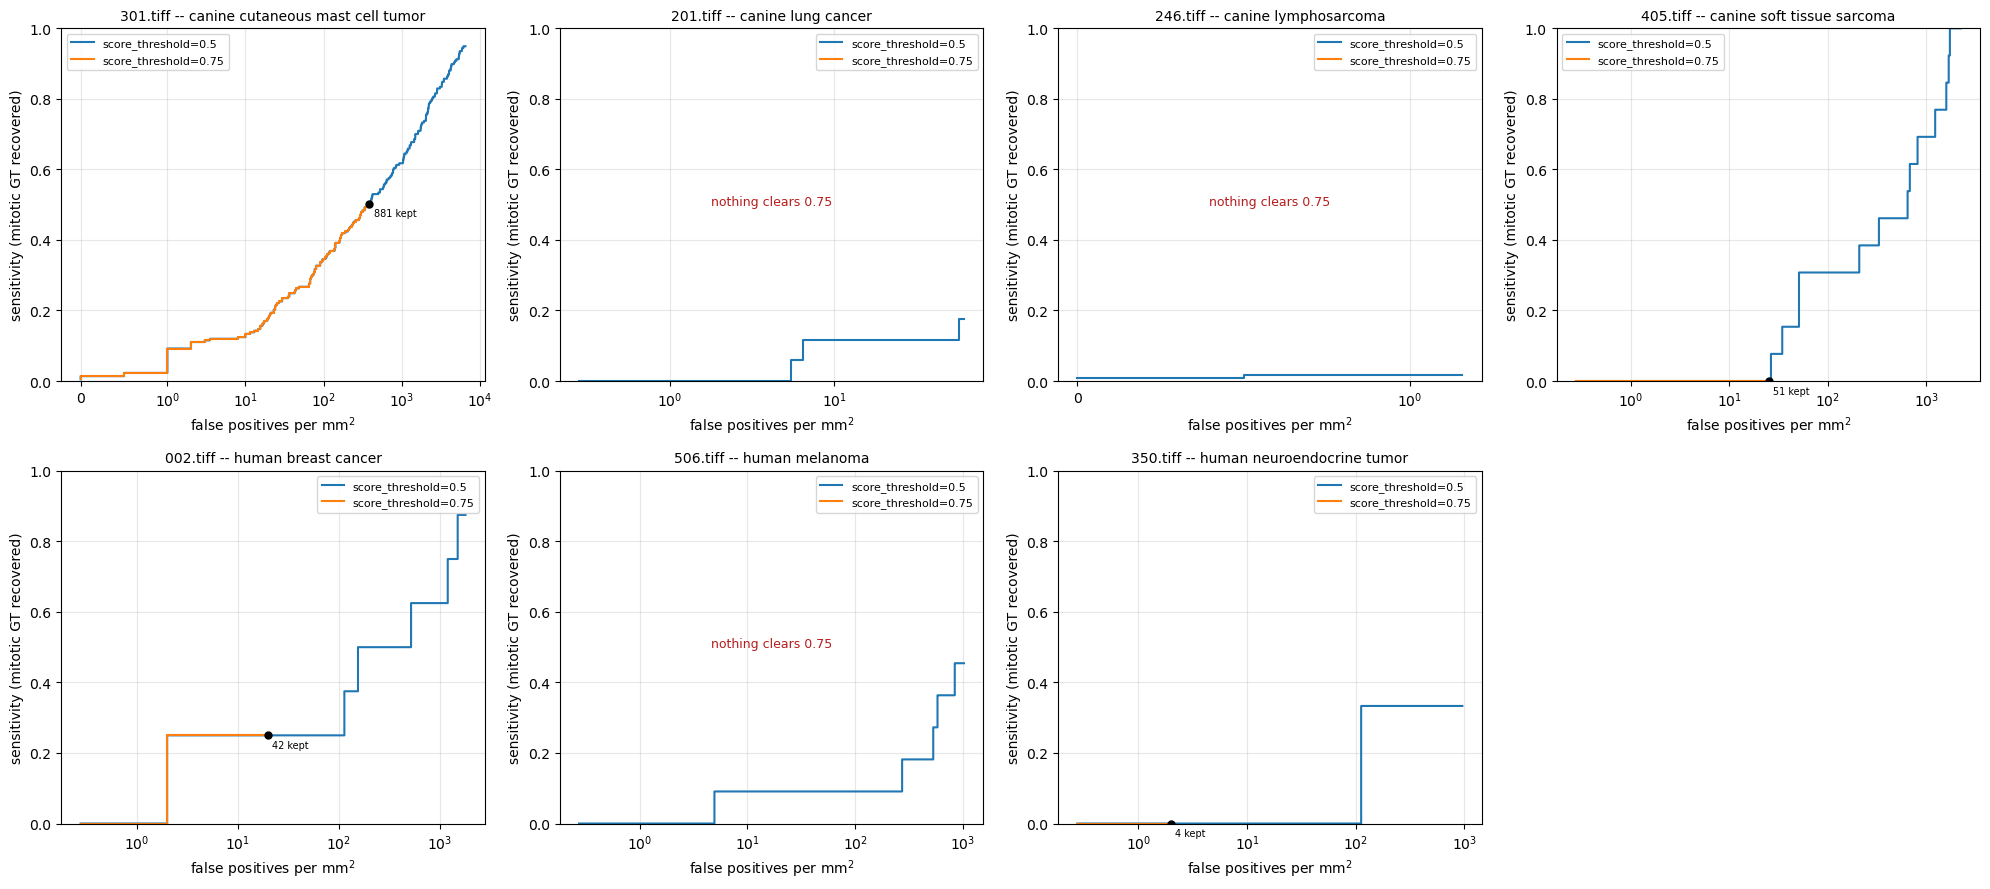

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, fn in zip(axes.ravel(), results.keys()):
    n_mit = int(old_fs.loc[fn, 'n_gt_mitotic_eval'])
    area = float(old_fs.loc[fn, 'roi_area_mm2'])
    g = old_det[old_det.file_name == fn].sort_values('rank')
    old_curve = ev.froc(g['bucket'].to_numpy(), n_mit, area)
    curves = [(f'score_threshold={BASELINE_THRESHOLD}', *old_curve),
              (f'score_threshold={SCORE_THRESHOLD}', *results[fn]['curve'])]
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.froc_plot(curves, ax=ax, title=f'{fn} -- {tumor}')
    stop = int((g.score >= SCORE_THRESHOLD).sum())
    if stop:
        ax.plot(old_curve[0][stop - 1], old_curve[1][stop - 1], 'o', color='k', ms=5,
                zorder=5, label='_')
        ax.annotate(f'{stop} kept', (old_curve[0][stop - 1], old_curve[1][stop - 1]),
                    fontsize=7, xytext=(3, -9), textcoords='offset points')
    else:
        ax.annotate('nothing clears 0.75', (0.5, 0.5), xycoords='axes fraction',
                    fontsize=9, ha='center', color='#b71c1c')
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.tight_layout(); plt.show()

### Where the detections land

White star = the seed. Red = ground-truth mitotic figures, yellow = ground-truth
look-alikes. Detections are top-`K` only, coloured by bucket, drawn at the match radius.
An ROI with no circles at all is one where nothing cleared 0.75.

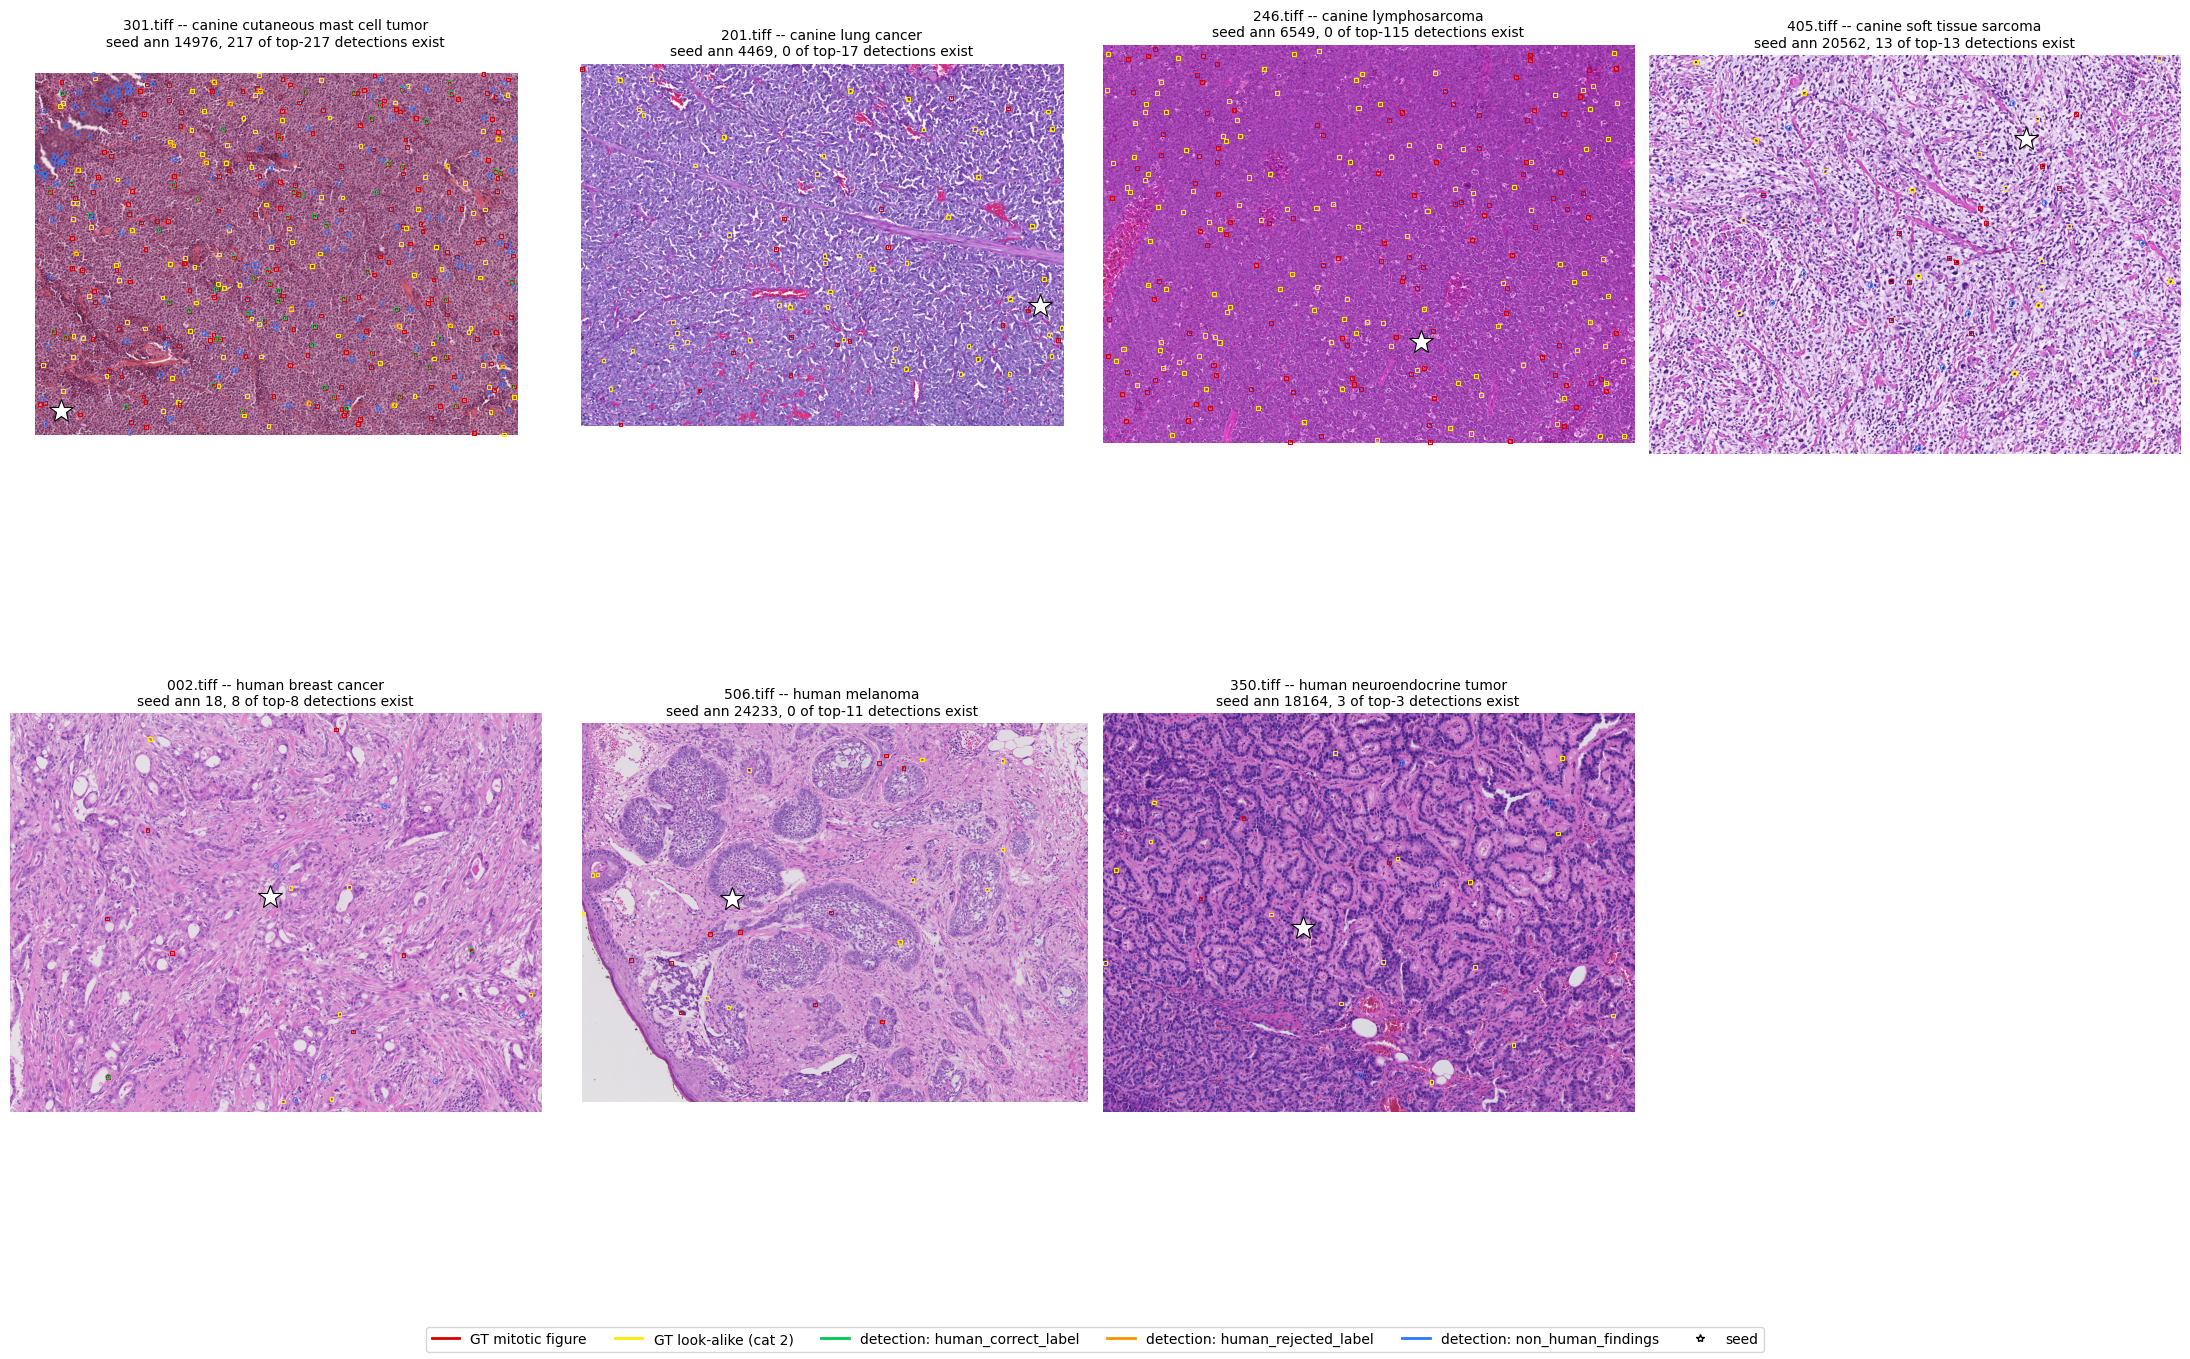

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(22, 15))
for ax, (fn, res) in zip(axes.ravel(), results.items()):
    rgb = ds.load_roi(f'images/{fn}')
    k = res['metrics'][0]['k']
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    n_shown = min(k, len(res['detections']))
    viz.overlay(rgb, res['gt'], res['detections'], (res['seed'].cx, res['seed'].cy),
                ax=ax, downsample=4, top_n=k, radius=res['radius'],
                title=f"{fn} -- {tumor}\nseed ann {int(res['seed'].ann_id)}, "
                      f"{n_shown} of top-{k} detections exist")
    del rgb
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.legend(handles=viz.legend_handles(), loc='lower center', ncol=6, fontsize=10)
fig.tight_layout(rect=(0, 0.03, 1, 1)); plt.show()

## Channel comparison at 0.75

Same two extra channels as the 0.5 notebook -- `hematoxylin` and `gray_inverted` -- with
`score_threshold=0.75` and nothing else changed. Seed selection and bbox tightening run
on the `gray_inverted` structural channel regardless of `cfg.channel`
([`experiment.py`](midog_utils/experiment.py)), and the per-image RNG is built from
`(seed, image_id)` alone, so all three channels see the same seed annotation and the same
tightened template size. That is asserted below, not assumed.

Baselines are not re-run: they do not depend on `cfg.channel`, and the RGB run above
already computed them at this threshold.

In [15]:
cfg_hematoxylin = fs.FSConfig(channel='hematoxylin', score_threshold=SCORE_THRESHOLD)
t0 = time.time()
results_hem, metrics_hem, detections_hem = ex.run_experiment(
    selection, annotations, cfg=cfg_hematoxylin, seed=0, run_baselines=False)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics_hem.to_csv('results/fs_t075_hematoxylin_metrics.csv', index=False)
detections_hem.to_csv('results/fs_t075_hematoxylin_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 


    recall@K=0.249  attraction@K=0.119  coverage=0.19  (10s)


=== 201.tiff  (canine lung cancer, 18 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.00  (8s)


=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 


...

=== 506.tiff  (human melanoma, 12 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.00  (9s)


=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.00  (7s)



total 56s


In [16]:
cfg_gray_inverted = fs.FSConfig(channel='gray_inverted', score_threshold=SCORE_THRESHOLD)
t0 = time.time()
results_gray, metrics_gray, detections_gray = ex.run_experiment(
    selection, annotations, cfg=cfg_gray_inverted, seed=0, run_baselines=False)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics_gray.to_csv('results/fs_t075_gray_inverted_metrics.csv', index=False)
detections_gray.to_csv('results/fs_t075_gray_inverted_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 


    recall@K=0.267  attraction@K=0.110  coverage=0.11  (4s)


=== 201.tiff  (canine lung cancer, 18 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.00  (4s)


=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 


...

=== 506.tiff  (human melanoma, 12 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.00  (5s)


=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.00  (5s)



total 31s


### Sanity check: apples-to-apples across channels, and against the 0.5 run

In [17]:
cfg_rgb = cfg
diffs = {f.name for f in fields(cfg_rgb)
         if not (asdict(cfg_rgb)[f.name] == asdict(cfg_hematoxylin)[f.name]
                 == asdict(cfg_gray_inverted)[f.name])}
assert diffs == {'channel'}, f'FSConfig fields other than channel differ: {diffs}'
assert {c.score_threshold for c in (cfg_rgb, cfg_hematoxylin, cfg_gray_inverted)} == {SCORE_THRESHOLD}
print('OK: the three configs differ only in `channel`, all at score_threshold='
      f'{SCORE_THRESHOLD}.')

key_cols = ['file_name', 'seed_ann_id', 'tightened_base_size']
m_rgb = metrics[metrics.method == 'find_and_suppress'][key_cols].set_index('file_name')
m_h = metrics_hem[key_cols].set_index('file_name')
m_g = metrics_gray[key_cols].set_index('file_name')
assert (m_rgb.seed_ann_id == m_h.seed_ann_id).all() and (m_rgb.seed_ann_id == m_g.seed_ann_id).all()
assert (m_rgb.tightened_base_size == m_h.tightened_base_size).all() and \
       (m_rgb.tightened_base_size == m_g.tightened_base_size).all()
print('OK: same seed_ann_id and tightened_base_size on all 7 images across all channels.')

# ...and the same seeds/templates the 0.5 notebook drew, so the two thresholds are
# comparable row by row.
old_cmp = pd.read_csv('results/fs_simple_channel_comparison_metrics.csv')
old_keys = old_cmp[old_cmp.channel == 'rgb'][key_cols].set_index('file_name')
assert (m_rgb.seed_ann_id == old_keys.seed_ann_id).all()
assert (m_rgb.tightened_base_size == old_keys.tightened_base_size).all()
print('OK: identical seeds and template sizes to the score_threshold=0.5 run.')

m_rgb.join(m_h, lsuffix='_rgb', rsuffix='_hem').join(m_g.add_suffix('_gray'))

OK: the three configs differ only in `channel`, all at score_threshold=0.75.
OK: same seed_ann_id and tightened_base_size on all 7 images across all channels.
OK: identical seeds and template sizes to the score_threshold=0.5 run.


,seed_ann_id_rgb,tightened_base_size_rgb,seed_ann_id_hem,tightened_base_size_hem,seed_ann_id_gray,tightened_base_size_gray
file_name,,,,,,
301.tiff,14976,35.0,14976,35,14976,35
201.tiff,4469,51.0,4469,51,4469,51
246.tiff,6549,51.0,6549,51,6549,51
405.tiff,20562,51.0,20562,51,20562,51
002.tiff,18,35.0,18,35,18,35
506.tiff,24233,43.0,24233,43,24233,43
350.tiff,18164,41.0,18164,41,18164,41


### `recall@K` by channel, at 0.75

In [18]:
combined = pd.concat([metrics[metrics.method == 'find_and_suppress'],
                      metrics_hem, metrics_gray], ignore_index=True)
combined.to_csv('results/fs_t075_channel_comparison_metrics.csv', index=False)

channel_pivot = combined.pivot_table(
    index=['tumor_type', 'file_name'], columns='channel',
    values=['recall_at_k', 'lookalike_attraction_at_k', 'coverage_frac',
            'n_detections_total', 'max_detection_score']
).round(3)
channel_pivot

coverage_frac                    lookalike_attraction_at_k                    max_detection_score                    n_detections_total                     \
channel                                    gray_inverted hematoxylin    rgb             gray_inverted hematoxylin    rgb       gray_inverted hematoxylin    rgb      gray_inverted hematoxylin    rgb   
tumor_type                       file_name                                                                                                                                                              
canine cutaneous mast cell tumor 301.tiff          0.105       0.188  0.075                      0.11       0.119  0.138               0.912       0.943  0.904             1244.0      2264.0  881.0   
canine lung cancer               201.tiff          0.000       0.000  0.000                      0.00       0.000  0.000                 NaN         NaN    NaN                0.0         0.0    0.0   
canine lymphosarcoma             246.tiff          0.000       0.000  0.000                      0.00       0.000  0.000                 NaN         NaN    NaN                0.0         0.0    0.0   
canine soft tissue sarcoma       405.tiff          0.008       0.022  0.004                      0.00       0.000  0.000               0.840       0.844  0.829               92.0       256.0   51.0   
human breast cancer              002.tiff          0.008       0.010  0.004                      0.00       0.000  0.000               0.830       0.841  0.808               87.0       117.0   42.0   
human melanoma                   506.tiff          0.000       0.001  0.000                      0.00       0.000  0.000               0.755       0.782    NaN                3.0        10.0    0.0   
human neuroendocrine tumor       350.tiff          0.001       0.001  0.000                      0.00       0.000  0.000               0.795       0.796  0.778               12.0        14.0    4.0   

                                             recall_at_k                     
channel                                    gray_inverted hematoxylin    rgb  
tumor_type                       file_name                                   
canine cutaneous mast cell tumor 301.tiff          0.267       0.249  0.304  
canine lung cancer               201.tiff          0.000       0.000  0.000  
canine lymphosarcoma             246.tiff          0.000       0.000  0.000  
canine soft tissue sarcoma       405.tiff          0.000       0.000  0.000  
human breast cancer              002.tiff          0.125       0.000  0.250  
human melanoma                   506.tiff          0.000       0.000  0.000  
human neuroendocrine tumor       350.tiff          0.000       0.000  0.000

### The same comparison against 0.5, per channel

`n_detections_total` and `recall_at_k` at both thresholds for all three channels. The
`delta` columns are what a threshold change bought (or cost) on each row.

In [19]:
old_all = old_cmp[old_cmp.method == 'find_and_suppress'][
    ['file_name', 'channel', 'recall_at_k', 'n_detections_total', 'coverage_frac',
     'max_detection_score']].rename(columns=lambda c: c + '_0.5' if c not in
                                    ('file_name', 'channel') else c)
new_all = combined[['file_name', 'channel', 'tumor_type', 'recall_at_k',
                    'n_detections_total', 'coverage_frac']].rename(
    columns=lambda c: c + '_0.75' if c not in ('file_name', 'channel', 'tumor_type') else c)
both = new_all.merge(old_all, on=['file_name', 'channel'])
both['delta_recall'] = (both['recall_at_k_0.75'] - both['recall_at_k_0.5']).round(3)
both['emptied'] = both['n_detections_total_0.75'] == 0
both = both.sort_values(['tumor_type', 'channel']).reset_index(drop=True)
both[['tumor_type', 'file_name', 'channel', 'max_detection_score_0.5',
      'n_detections_total_0.5', 'n_detections_total_0.75', 'recall_at_k_0.5',
      'recall_at_k_0.75', 'delta_recall', 'emptied', 'coverage_frac_0.5',
      'coverage_frac_0.75']].round(3)

,tumor_type,file_name,channel,max_detection_score_0.5,n_detections_total_0.5,n_detections_total_0.75,recall_at_k_0.5,recall_at_k_0.75,delta_recall,emptied,coverage_frac_0.5,coverage_frac_0.75
0,canine cutaneous mast cell tumor,301.tiff,gray_inverted,0.912,13615,1244,0.267,0.267,0.000,False,0.847,0.105
1,canine cutaneous mast cell tumor,301.tiff,hematoxylin,0.943,14428,2264,0.249,0.249,0.000,False,0.873,0.188
2,canine cutaneous mast cell tumor,301.tiff,rgb,0.904,13353,881,0.304,0.304,0.000,False,0.836,0.075
3,canine lung cancer,201.tiff,gray_inverted,0.639,188,0,0.059,0.000,-0.059,True,0.016,0.000
4,canine lung cancer,201.tiff,hematoxylin,0.674,513,0,0.176,0.000,-0.176,True,0.045,0.000
5,canine lung cancer,201.tiff,rgb,0.636,127,0,0.118,0.000,-0.118,True,0.011,0.000
6,canine lymphosarcoma,246.tiff,gray_inverted,0.623,23,0,0.017,0.000,-0.017,True,0.002,0.000
7,canine lymphosarcoma,246.tiff,hematoxylin,0.584,35,0,0.122,0.000,-0.122,True,0.003,0.000
8,canine lymphosarcoma,246.tiff,rgb,0.599,5,0,0.017,0.000,-0.017,True,0.000,0.000
9,canine soft tissue sarcoma,405.tiff,gray_inverted,0.840,4881,92,0.000,0.000,0.000,False,0.403,0.008


In [20]:
print(f"improved: {(both.delta_recall > 0).sum()} / {len(both)} rows")
print(f"unchanged: {(both.delta_recall == 0).sum()} / {len(both)} rows")
print(f"worse:     {(both.delta_recall < 0).sum()} / {len(both)} rows")
print(f"emptied to zero detections: {both.emptied.sum()} / {len(both)} rows")
print(f"\nmean recall@K by channel:")
print(both.groupby('channel')[['recall_at_k_0.5', 'recall_at_k_0.75']].mean().round(3))

improved: 0 / 21 rows
unchanged: 14 / 21 rows
worse:     7 / 21 rows
emptied to zero detections: 7 / 21 rows

mean recall@K by channel:
               recall_at_k_0.5  recall_at_k_0.75
channel                                         
gray_inverted            0.067             0.056
hematoxylin              0.078             0.036
rgb                      0.111             0.079


### Every detection, not just top-K -- by channel

In [21]:
full_list_rows = []
for chan, g in combined.groupby('channel'):
    t = ex.full_list_table(g, method=None)
    t.insert(0, 'channel', chan)
    full_list_rows.append(t)
pd.concat(full_list_rows, ignore_index=True).sort_values(
    ['tumor_type', 'channel']).reset_index(drop=True)

,channel,tumor_type,file_name,all_n_detections,coverage_frac,all_tp,all_fp_lookalike,all_fp_unannotated,all_matched_any_gt,all_matched_frac,all_precision_mitotic,all_mitotic_gt_found,all_mitotic_gt_missed,all_lookalike_gt_found,all_lookalike_gt_missed
0,gray_inverted,canine cutaneous mast cell tumor,301.tiff,1244,0.1053,114,29,1101,143,0.114952,0.091640,114,103,29,80
1,hematoxylin,canine cutaneous mast cell tumor,301.tiff,2264,0.1877,133,50,2081,183,0.080830,0.058746,133,84,50,59
2,rgb,canine cutaneous mast cell tumor,301.tiff,881,0.0752,109,27,745,136,0.154370,0.123723,109,108,27,82
3,gray_inverted,canine lung cancer,201.tiff,0,0.0000,0,0,0,0,0.000000,0.000000,0,17,0,49
4,hematoxylin,canine lung cancer,201.tiff,0,0.0000,0,0,0,0,0.000000,0.000000,0,17,0,49
5,rgb,canine lung cancer,201.tiff,0,0.0000,0,0,0,0,0.000000,0.000000,0,17,0,49
6,gray_inverted,canine lymphosarcoma,246.tiff,0,0.0000,0,0,0,0,0.000000,0.000000,0,115,0,123
7,hematoxylin,canine lymphosarcoma,246.tiff,0,0.0000,0,0,0,0,0.000000,0.000000,0,115,0,123
8,rgb,canine lymphosarcoma,246.tiff,0,0.0000,0,0,0,0,0.000000,0.000000,0,115,0,123
9,gray_inverted,canine soft tissue sarcoma,405.tiff,92,0.0081,2,2,88,4,0.043478,0.021739,2,11,2,17


### FROC by channel, at 0.75

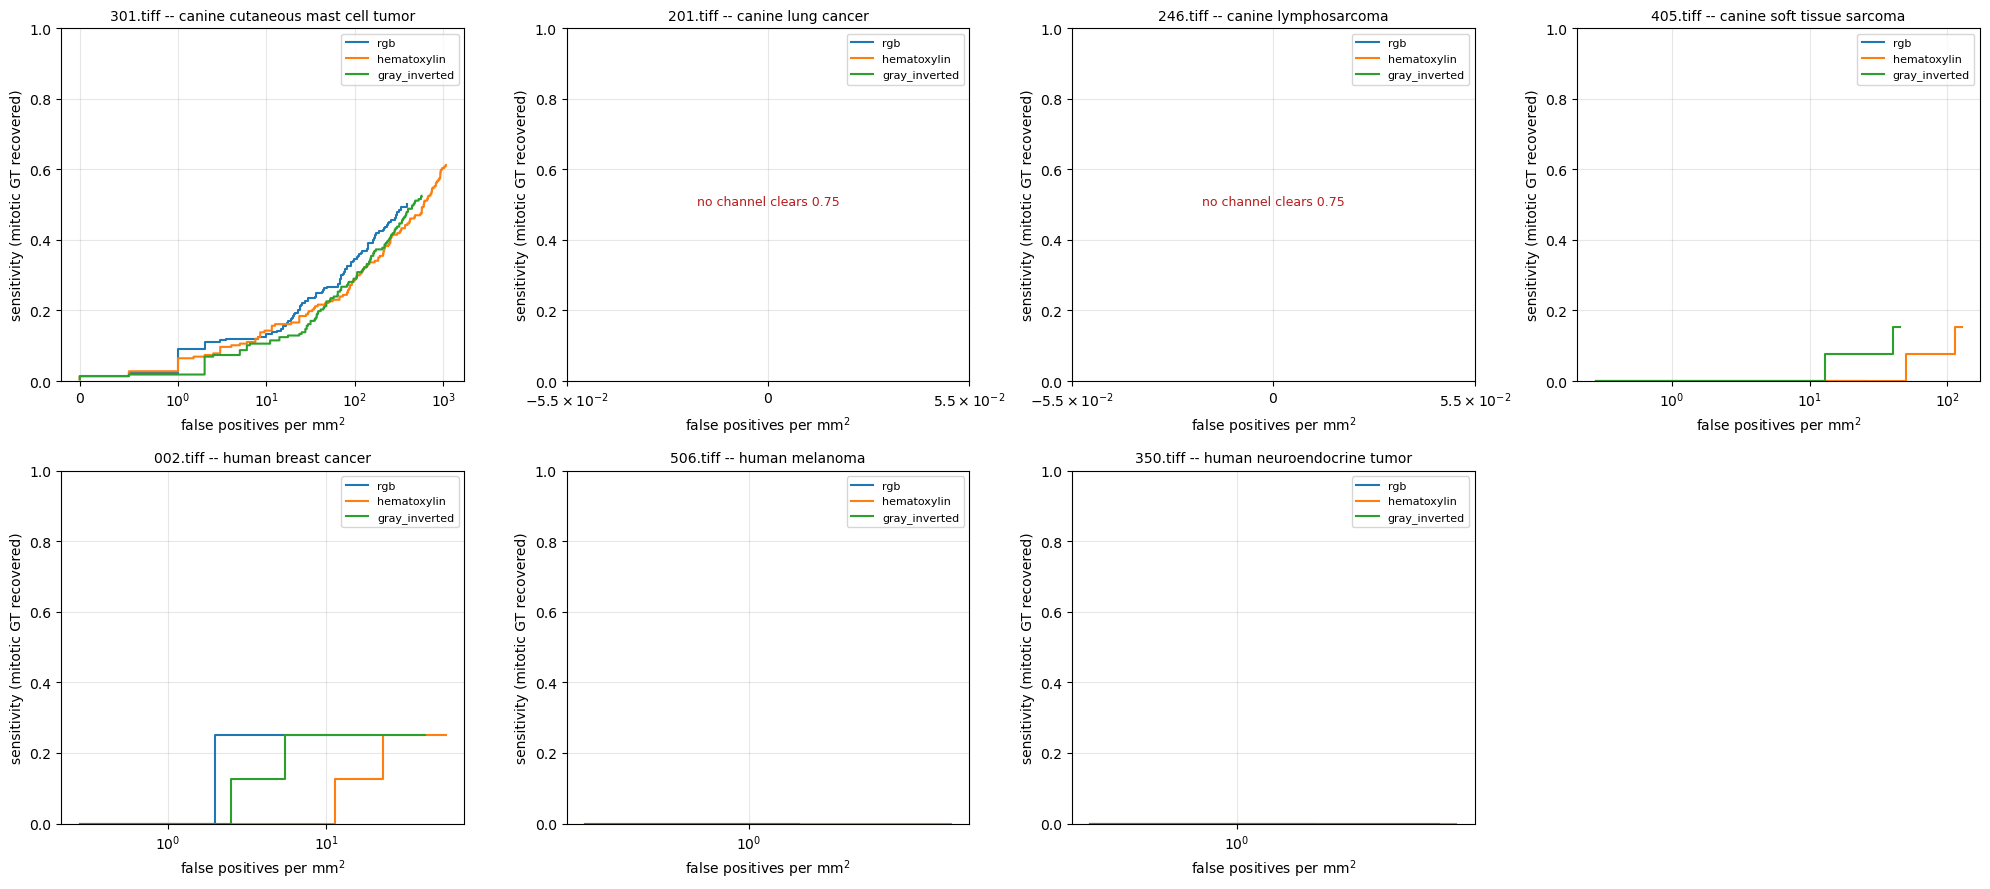

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, fn in zip(axes.ravel(), results.keys()):
    curves = [('rgb', *results[fn]['curve']),
              ('hematoxylin', *results_hem[fn]['curve']),
              ('gray_inverted', *results_gray[fn]['curve'])]
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.froc_plot(curves, ax=ax, title=f'{fn} -- {tumor}')
    if all(len(c[1]) == 0 for c in curves):
        ax.annotate('no channel clears 0.75', (0.5, 0.5), xycoords='axes fraction',
                    fontsize=9, ha='center', color='#b71c1c')
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.tight_layout(); plt.show()

### Full-list recall by channel

In [23]:
fulllist_pivot = combined.pivot_table(
    index=['tumor_type', 'file_name'], columns='channel',
    values=['mitotic_recall', 'coverage_frac', 'n_detections_total']
).round(3)
fulllist_pivot.reindex(columns=['gray_inverted', 'hematoxylin', 'rgb'], level=1)

coverage_frac                    mitotic_recall                    n_detections_total                   
channel                                    gray_inverted hematoxylin    rgb  gray_inverted hematoxylin    rgb      gray_inverted hematoxylin    rgb
tumor_type                       file_name                                                                                                         
canine cutaneous mast cell tumor 301.tiff          0.105       0.188  0.075          0.525       0.613  0.502             1244.0      2264.0  881.0
canine lung cancer               201.tiff          0.000       0.000  0.000          0.000       0.000  0.000                0.0         0.0    0.0
canine lymphosarcoma             246.tiff          0.000       0.000  0.000          0.000       0.000  0.000                0.0         0.0    0.0
canine soft tissue sarcoma       405.tiff          0.008       0.022  0.004          0.154       0.154  0.000               92.0       256.0   51.0
human breast cancer              002.tiff          0.008       0.010  0.004          0.250       0.250  0.250               87.0       117.0   42.0
human melanoma                   506.tiff          0.000       0.001  0.000          0.000       0.000  0.000                3.0        10.0    0.0
human neuroendocrine tumor       350.tiff          0.001       0.001  0.000          0.000       0.000  0.000               12.0        14.0    4.0

## The threshold-free probe is unchanged, by construction

[`experiment._probe_variants`](midog_utils/experiment.py) reads the fused correlation
value directly at every annotated location, every detected-nucleus centroid, and 3000
random tissue points. It never extracts peaks, never runs NMS, and never reads
`score_threshold` -- so re-running it at 0.75 would burn ~5 minutes to reproduce
`results/fs_simple_channel_probe.csv` byte for byte. It is loaded here instead.

That is not a shortcut; it is the cleanest evidence in the notebook. `auc_mitosis_vs_nucleus`
(P a random mitotic figure outscores a random ordinary nucleus) and `discrimination`
(that AUC minus the look-alike-vs-nucleus AUC -- the mitosis-*specific* part of the
signal) are **provably identical** at both thresholds. Whatever the score floor did, it
did not change how well the correlation map separates mitosis from anything else.

In [24]:
channel_probe = pd.read_csv('results/fs_simple_channel_probe.csv')
probe_pivot = channel_probe.merge(
    selection[['file_name', 'tumor_type']], on='file_name'
).pivot_table(index=['tumor_type', 'file_name'], columns='variant',
              values=['auc_mitosis_vs_nucleus', 'discrimination',
                      'median_mitosis_rank']).round(3)
probe_pivot.reindex(columns=['gray_inverted', 'hematoxylin', 'rgb'], level=1)

auc_mitosis_vs_nucleus                    discrimination                    median_mitosis_rank                    
variant                                             gray_inverted hematoxylin    rgb  gray_inverted hematoxylin    rgb       gray_inverted hematoxylin     rgb
tumor_type                       file_name                                                                                                                    
canine cutaneous mast cell tumor 301.tiff                   0.735       0.762  0.743          0.148       0.070  0.140              1788.0       723.0  1753.0
canine lung cancer               201.tiff                   0.805       0.861  0.827         -0.032      -0.038 -0.034               866.0       175.0   392.0
canine lymphosarcoma             246.tiff                   0.761       0.843  0.797          0.093       0.058  0.096              2072.0       595.0  1488.0
canine soft tissue sarcoma       405.tiff                   0.719       0.592  0.702          0.002      -0.167 -0.032              1419.0      2593.0  1114.0
human breast cancer              002.tiff                   0.914       0.895  0.923          0.044       0.043  0.045               217.0       315.0   200.0
human melanoma                   506.tiff                   0.744       0.748  0.773          0.076       0.088  0.092              2496.0      2556.0  2396.0
human neuroendocrine tumor       350.tiff                   0.738       0.859  0.796          0.034       0.172  0.080              1747.0       823.0  1390.0

In [25]:
# The number the whole experiment turns on, restated: where the typical mitotic figure
# lands among the ROI's ordinary nuclei, against the budget K it would have to beat.
rank_vs_k = channel_probe.pivot_table(index='file_name', columns='variant',
                                      values='median_mitosis_rank')
rank_vs_k['K'] = rank_vs_k.index.map(old_fs['k'])
rank_vs_k.merge(selection.set_index('file_name')[['tumor_type']],
                left_index=True, right_index=True).sort_values('tumor_type')

,gray_inverted,hematoxylin,rgb,K,tumor_type
file_name,,,,,
301.tiff,1788.0,723.0,1753.0,217,canine cutaneous mast cell tumor
201.tiff,866.0,175.0,392.0,17,canine lung cancer
246.tiff,2072.0,595.0,1488.0,115,canine lymphosarcoma
405.tiff,1419.0,2593.0,1114.0,13,canine soft tissue sarcoma
002.tiff,217.0,315.0,200.0,8,human breast cancer
506.tiff,2496.0,2556.0,2396.0,11,human melanoma
350.tiff,1747.0,823.0,1390.0,3,human neuroendocrine tumor


## Conclusion

**More decisive: yes, trivially. Better: no, and not as an empirical accident -- it could
not have been.**

The run reproduced the prediction on every one of the 21 (image x channel) rows: the
detection list at 0.75 is exactly the 0.5 list filtered to `score >= 0.75`, coordinate for
coordinate, with zero set differences on any image (verification cell above), and every
observed `recall@K` equals the value derived from the saved 0.5 detection file before this
notebook ran a single correlation.

**Headline, RGB (the notebook's primary configuration):**

| | 0.5 | 0.75 |
|---|---|---|
| rows where `recall@K` improved | -- | **0 / 7** |
| rows unchanged | -- | 4 / 7 |
| rows worse | -- | 3 / 7 |
| mean `recall@K` | 0.111 | **0.079** |
| mean `coverage_frac` | 0.263 | 0.012 |
| total detections | 25 592 | 978 |

Across all three channels: **0 / 21 rows improved, 14 unchanged, 7 got worse**, and all
seven of those became worse in the same way -- the list emptied completely. Mean
`recall@K` fell for every channel (`rgb` 0.111 -> 0.079, `hematoxylin` 0.078 -> 0.036,
`gray_inverted` 0.067 -> 0.056).

**Why three ROIs collapse to zero.** 201.tiff, 246.tiff and 506.tiff have best genuine
(non-self) match scores of 0.64, 0.60 and 0.74 -- all below 0.75. The floor was set above
everything the matcher found there, so those ROIs return an empty detection list, a FROC
curve with no points, and `recall@K = 0`. That is the floor being miscalibrated for those
images, not the matcher performing worse on them.

**Why "decisive" is the wrong word for what improved.** `coverage_frac` falls by an
order of magnitude on every row -- a mechanical consequence of a shorter list, not a
property of the detector. `all_precision_mitotic` is the more revealing column, because it
does *not* uniformly rise: it improves only on the two rows where a true positive survives
the truncation (301.tiff 0.015 -> 0.124, an 8x gain; 002.tiff 0.002 -> 0.048), and on the
other five it falls to zero -- genuinely 0/51 and 0/4 on 405.tiff and 350.tiff, and an
undefined 0/0 rendered as 0.0000 on the three emptied ROIs. Truncating a signal-bearing
ranked list higher raises precision only while the surviving prefix still contains a hit;
cut above every hit and the same operation drives it to zero. Both columns describe where
on the curve the pipeline is being read, not the shape of the curve -- the FROC panels
show this directly, with the 0.75 curve lying exactly on the 0.5 curve and simply
stopping.

The one genuine benefit is interpretability, and it is real but narrow: `coverage_frac`
at 0.5 was 0.29-0.84 on four ROIs, high enough that full-list recall there was partly a
statement about the detection list tiling the image. At 0.75 coverage is <= 0.08
everywhere, so full-list numbers mean what they say -- on the four rows where any
detections survive at all.

**The threshold-free evidence is unchanged by construction.** `auc_mitosis_vs_nucleus`
(0.59-0.92 across these ROIs) and `discrimination` (-0.17 to +0.17, straddling zero) come
from the fused correlation map read directly, with no peaks, no NMS and no score floor in
the loop. They are provably identical at 0.5 and 0.75. Nothing about how well this
template matcher separates mitosis from an ordinary nucleus changed, because the score
floor is not the thing that determines it. `median_mitosis_rank` still puts the typical
mitotic figure 200-2600 ordinary nuclei down the ranking against a budget `K` of 3-217 --
the base-rate problem documented in `Research Logs/design_choices.md`, which no choice of
threshold addresses.

**Recommendation.** Keep `score_threshold=0.5`. If the goal is shorter, more precise
lists, truncate the 0.5 list by rank or by score at report time -- that is exactly what
0.75 does, but it keeps the option of reading further down the list on ROIs whose whole
score distribution sits low, instead of discarding them. A fixed absolute floor is the
wrong instrument here: `TM_CCOEFF_NORMED` scores are not comparable across ROIs (template
size varies 35-51 px between images, and its null variance depends on template size), so
one number cannot mean the same thing on 301.tiff and on 246.tiff. If a floor is wanted
at all, a per-image one -- a quantile of that ROI's own peak distribution -- would at
least be a consistent operating point rather than a different one per image.